<a href="https://colab.research.google.com/github/Izumiiiii17/AI-ML/blob/main/AIML_LABSHEET9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

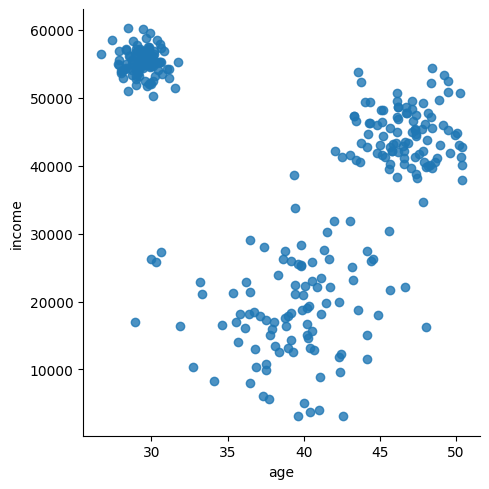

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/Income Data.csv")
sns.lmplot(x="age", y="income", data=df, fit_reg=False)
plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_df=scaler.fit_transform(df[["age","income"]])
scaled_df[0:5]

array([[ 1.3701637 ,  0.09718548],
       [-1.3791283 ,  0.90602749],
       [ 1.10388844,  0.51405021],
       [ 0.23849387, -1.27162408],
       [-0.35396857, -1.32762083]])

In [12]:
from sklearn.cluster import KMeans
clusters=KMeans(3)
clusters.fit(scaled_df)
df["new_clusterid"]=clusters.labels_
df.groupby("new_clusterid")[['age','income']].agg(["median",'std']).reset_index()

new_clusterid     age             income             
                 median       std   median          std
0             0  29.375  0.921458  55200.0  1951.943864
1             1  46.700  2.151559  44300.0  4390.321503
2             2  39.450  3.558665  18200.0  6924.747691

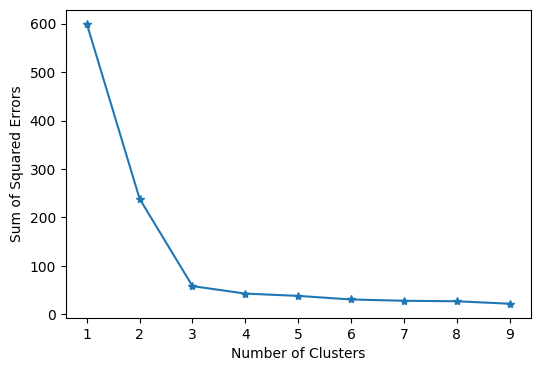

In [13]:
cluster_range=range(1,10)
cluster_errors=[]
for num_clusters in cluster_range:
  clusters=KMeans(num_clusters)
  clusters.fit(scaled_df)
  cluster_errors.append(clusters.inertia_)
plt.figure(figsize=(6,4))
plt.plot(cluster_range,cluster_errors,marker='*')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Errors')
plt.show()